In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_wrapper import (
    set_seed,
    EVENT_LABELS,
    EVENT_TO_ID,
    ID_TO_EVENT,
    SCENARIO_GROUPS,
    get_all_scenarios,
    generate_one_multilabel_series,
    generate_multilabel_dataset,
    summarize_multilabel_metadata
)

set_seed(42)

OUTPUT_DIR = Path("mmi711_outputs_multilabel")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Event labels:", EVENT_LABELS)
print("Output directory:", OUTPUT_DIR)

Event labels: ['mean_shift', 'variance_shift', 'trend_shift', 'point_anomaly', 'collective_anomaly']
Output directory: mmi711_outputs_multilabel


In [2]:
all_scenarios = get_all_scenarios()

print("Number of scenario patterns:", len(all_scenarios))
print()

for group_name, events in all_scenarios:
    scenario_name = "no_event" if len(events) == 0 else "+".join(events)
    print(f"{group_name:16s} | {scenario_name}")

Number of scenario patterns: 16

no_event         | no_event
single_event     | mean_shift
single_event     | variance_shift
single_event     | trend_shift
single_event     | point_anomaly
single_event     | collective_anomaly
anomaly_anomaly  | point_anomaly+collective_anomaly
shift_shift      | mean_shift+variance_shift
shift_shift      | mean_shift+trend_shift
shift_shift      | variance_shift+trend_shift
shift_anomaly    | mean_shift+point_anomaly
shift_anomaly    | mean_shift+collective_anomaly
shift_anomaly    | variance_shift+point_anomaly
shift_anomaly    | variance_shift+collective_anomaly
shift_anomaly    | trend_shift+point_anomaly
shift_anomaly    | trend_shift+collective_anomaly


In [3]:
LENGTHS = [ 400, 800, 1200]

# Final-ish settings for presentation:
# Train: 16 scenarios × 30 × 5 lengths = 2400 series
# Val:   16 scenarios × 8  × 5 lengths = 640 series
# OOD:   16 scenarios × 10 × 5 lengths = 800 series each

N_TRAIN_PER_SCENARIO_PER_LENGTH = 100
N_VAL_PER_SCENARIO_PER_LENGTH = 20
N_TEST_PER_SCENARIO_PER_LENGTH = 20

split_settings = {
    "train": {
        "split_mode": "train",
        "n_per_scenario": N_TRAIN_PER_SCENARIO_PER_LENGTH
    },
    "val": {
        "split_mode": "val",
        "n_per_scenario": N_VAL_PER_SCENARIO_PER_LENGTH
    },
    "ood_params": {
        "split_mode": "ood_params",
        "n_per_scenario": N_TEST_PER_SCENARIO_PER_LENGTH
    },
    "ood_background": {
        "split_mode": "ood_background",
        "n_per_scenario": N_TEST_PER_SCENARIO_PER_LENGTH
    }
}

print("Lengths:", LENGTHS)
print("Number of scenarios:", len(all_scenarios))

Lengths: [400, 800, 1200]
Number of scenarios: 16


In [4]:
arrays_to_save = {}
metadata_tables = []

for split_name, settings in split_settings.items():
    for length in LENGTHS:
        print("=" * 70)
        print(f"Generating split={split_name}, length={length}")
        print("=" * 70)

        X, Y, meta = generate_multilabel_dataset(
            n_per_scenario=settings["n_per_scenario"],
            length=length,
            split_mode=settings["split_mode"]
        )

        arrays_to_save[f"X_{split_name}_L{length}"] = X
        arrays_to_save[f"Y_{split_name}_L{length}"] = Y

        meta = meta.copy()
        meta["dataset"] = split_name
        meta["length"] = length
        metadata_tables.append(meta)

        print("X shape:", X.shape)
        print("Y shape:", Y.shape)
        print("Scenario counts:")
        print(meta["scenario"].value_counts().sort_index())
        print()

Generating split=train, length=400
X shape: (1600, 400)
Y shape: (1600, 5)
Scenario counts:
scenario
collective_anomaly                   100
mean_shift                           100
mean_shift+collective_anomaly        100
mean_shift+point_anomaly             100
mean_shift+trend_shift               100
mean_shift+variance_shift            100
no_event                             100
point_anomaly                        100
point_anomaly+collective_anomaly     100
trend_shift                          100
trend_shift+collective_anomaly       100
trend_shift+point_anomaly            100
variance_shift                       100
variance_shift+collective_anomaly    100
variance_shift+point_anomaly         100
variance_shift+trend_shift           100
Name: count, dtype: int64

Generating split=train, length=800
X shape: (1600, 800)
Y shape: (1600, 5)
Scenario counts:
scenario
collective_anomaly                   100
mean_shift                           100
mean_shift+collective_anomaly    

In [5]:
# Save all arrays in one compressed NumPy archive
np.savez_compressed(
    OUTPUT_DIR / "mmi711_multilabel_variable_length_datasets.npz",
    **arrays_to_save
)

# Save metadata
all_metadata = pd.concat(metadata_tables, ignore_index=True)
all_metadata.to_csv(
    OUTPUT_DIR / "meta_all_multilabel_variable_lengths.csv",
    index=False
)

# Save separate metadata files per split
for split_name in split_settings.keys():
    split_meta = all_metadata[all_metadata["dataset"] == split_name]
    split_meta.to_csv(
        OUTPUT_DIR / f"meta_{split_name}.csv",
        index=False
    )

# Save dataset config
dataset_config = {
    "dataset_type": "multi_label_variable_length",
    "lengths": LENGTHS,
    "event_labels": EVENT_LABELS,
    "event_to_id": EVENT_TO_ID,
    "scenario_groups": SCENARIO_GROUPS,
    "n_train_per_scenario_per_length": N_TRAIN_PER_SCENARIO_PER_LENGTH,
    "n_val_per_scenario_per_length": N_VAL_PER_SCENARIO_PER_LENGTH,
    "n_test_per_scenario_per_length": N_TEST_PER_SCENARIO_PER_LENGTH,
    "description": {
        "target_format": "Multi-label binary vector. no_event is represented by all-zero target vector.",
        "train": "In-distribution training set with none/linear backgrounds.",
        "val": "In-distribution validation set with none/linear backgrounds.",
        "ood_params": "OOD test set with shifted event parameters.",
        "ood_background": "OOD test set with harder seasonal or linear-seasonal backgrounds."
    }
}

with open(OUTPUT_DIR / "dataset_config_multilabel_variable_lengths.json", "w") as f:
    json.dump(dataset_config, f, indent=4)

print("Saved all datasets and metadata.")
print("Output directory:", OUTPUT_DIR)

Saved all datasets and metadata.
Output directory: mmi711_outputs_multilabel


In [6]:

OUTPUT_DIR = Path("mmi711_outputs_multilabel")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

In [7]:
data = np.load(OUTPUT_DIR / "mmi711_multilabel_variable_length_datasets.npz")

for key in data.files:
    arr = data[key]

    print("\n", key)
    print("finite:", np.isfinite(arr).all())
    print("nan count:", np.isnan(arr).sum())
    print("inf count:", np.isinf(arr).sum())

    if key.startswith("X"):
        print("max abs:", np.max(np.abs(arr)))


 X_train_L400
finite: True
nan count: 0
inf count: 0
max abs: 7.3691196

 Y_train_L400
finite: True
nan count: 0
inf count: 0

 X_train_L800
finite: True
nan count: 0
inf count: 0
max abs: 7.2014656

 Y_train_L800
finite: True
nan count: 0
inf count: 0

 X_train_L1200
finite: True
nan count: 0
inf count: 0
max abs: 10.0

 Y_train_L1200
finite: True
nan count: 0
inf count: 0

 X_val_L400
finite: True
nan count: 0
inf count: 0
max abs: 6.777832

 Y_val_L400
finite: True
nan count: 0
inf count: 0

 X_val_L800
finite: True
nan count: 0
inf count: 0
max abs: 6.559477

 Y_val_L800
finite: True
nan count: 0
inf count: 0

 X_val_L1200
finite: True
nan count: 0
inf count: 0
max abs: 8.844768

 Y_val_L1200
finite: True
nan count: 0
inf count: 0

 X_ood_params_L400
finite: True
nan count: 0
inf count: 0
max abs: 5.6375456

 Y_ood_params_L400
finite: True
nan count: 0
inf count: 0

 X_ood_params_L800
finite: True
nan count: 0
inf count: 0
max abs: 7.092778

 Y_ood_params_L800
finite: True
nan cou

In [8]:
print("Saved arrays:")
print("-" * 50)

for key in sorted(arrays_to_save.keys()):
    print(f"{key:30s} {arrays_to_save[key].shape}")

print("\nMetadata shape:", all_metadata.shape)

print("\nFiles saved:")
for file in sorted(OUTPUT_DIR.iterdir()):
    print(file.name)

Saved arrays:
--------------------------------------------------
X_ood_background_L1200         (320, 1200)
X_ood_background_L400          (320, 400)
X_ood_background_L800          (320, 800)
X_ood_params_L1200             (320, 1200)
X_ood_params_L400              (320, 400)
X_ood_params_L800              (320, 800)
X_train_L1200                  (1600, 1200)
X_train_L400                   (1600, 400)
X_train_L800                   (1600, 800)
X_val_L1200                    (320, 1200)
X_val_L400                     (320, 400)
X_val_L800                     (320, 800)
Y_ood_background_L1200         (320, 5)
Y_ood_background_L400          (320, 5)
Y_ood_background_L800          (320, 5)
Y_ood_params_L1200             (320, 5)
Y_ood_params_L400              (320, 5)
Y_ood_params_L800              (320, 5)
Y_train_L1200                  (1600, 5)
Y_train_L400                   (1600, 5)
Y_train_L800                   (1600, 5)
Y_val_L1200                    (320, 5)
Y_val_L400           

In [9]:
print("Overall dataset counts:")
print(all_metadata["dataset"].value_counts())

print("\nDataset x Length:")
print(pd.crosstab(all_metadata["dataset"], all_metadata["length"]))

print("\nDataset x Scenario Group:")
print(pd.crosstab(all_metadata["dataset"], all_metadata["scenario_group"]))

print("\nDataset x Background:")
print(pd.crosstab(all_metadata["dataset"], all_metadata["background"]))

print("\nScenario counts by dataset:")
print(pd.crosstab(all_metadata["scenario"], all_metadata["dataset"]))

Overall dataset counts:
dataset
train             4800
val                960
ood_params         960
ood_background     960
Name: count, dtype: int64

Dataset x Length:
length          400   800   1200
dataset                         
ood_background   320   320   320
ood_params       320   320   320
train           1600  1600  1600
val              320   320   320

Dataset x Scenario Group:
scenario_group  anomaly_anomaly  no_event  shift_anomaly  shift_shift  \
dataset                                                                 
ood_background               60        60            360          180   
ood_params                   60        60            360          180   
train                       300       300           1800          900   
val                          60        60            360          180   

scenario_group  single_event  
dataset                       
ood_background           300  
ood_params               300  
train                   1500  
val         

In [10]:
summary_dataset_length = pd.crosstab(
    all_metadata["dataset"],
    all_metadata["length"]
)

summary_dataset_scenario_group = pd.crosstab(
    all_metadata["dataset"],
    all_metadata["scenario_group"]
)

summary_dataset_background = pd.crosstab(
    all_metadata["dataset"],
    all_metadata["background"]
)

summary_scenario_dataset = pd.crosstab(
    all_metadata["scenario"],
    all_metadata["dataset"]
)

summary_dataset_length.to_csv(OUTPUT_DIR / "summary_dataset_by_length.csv")
summary_dataset_scenario_group.to_csv(OUTPUT_DIR / "summary_dataset_by_scenario_group.csv")
summary_dataset_background.to_csv(OUTPUT_DIR / "summary_dataset_by_background.csv")
summary_scenario_dataset.to_csv(OUTPUT_DIR / "summary_scenario_by_dataset.csv")

print("Summary tables saved.")

Summary tables saved.


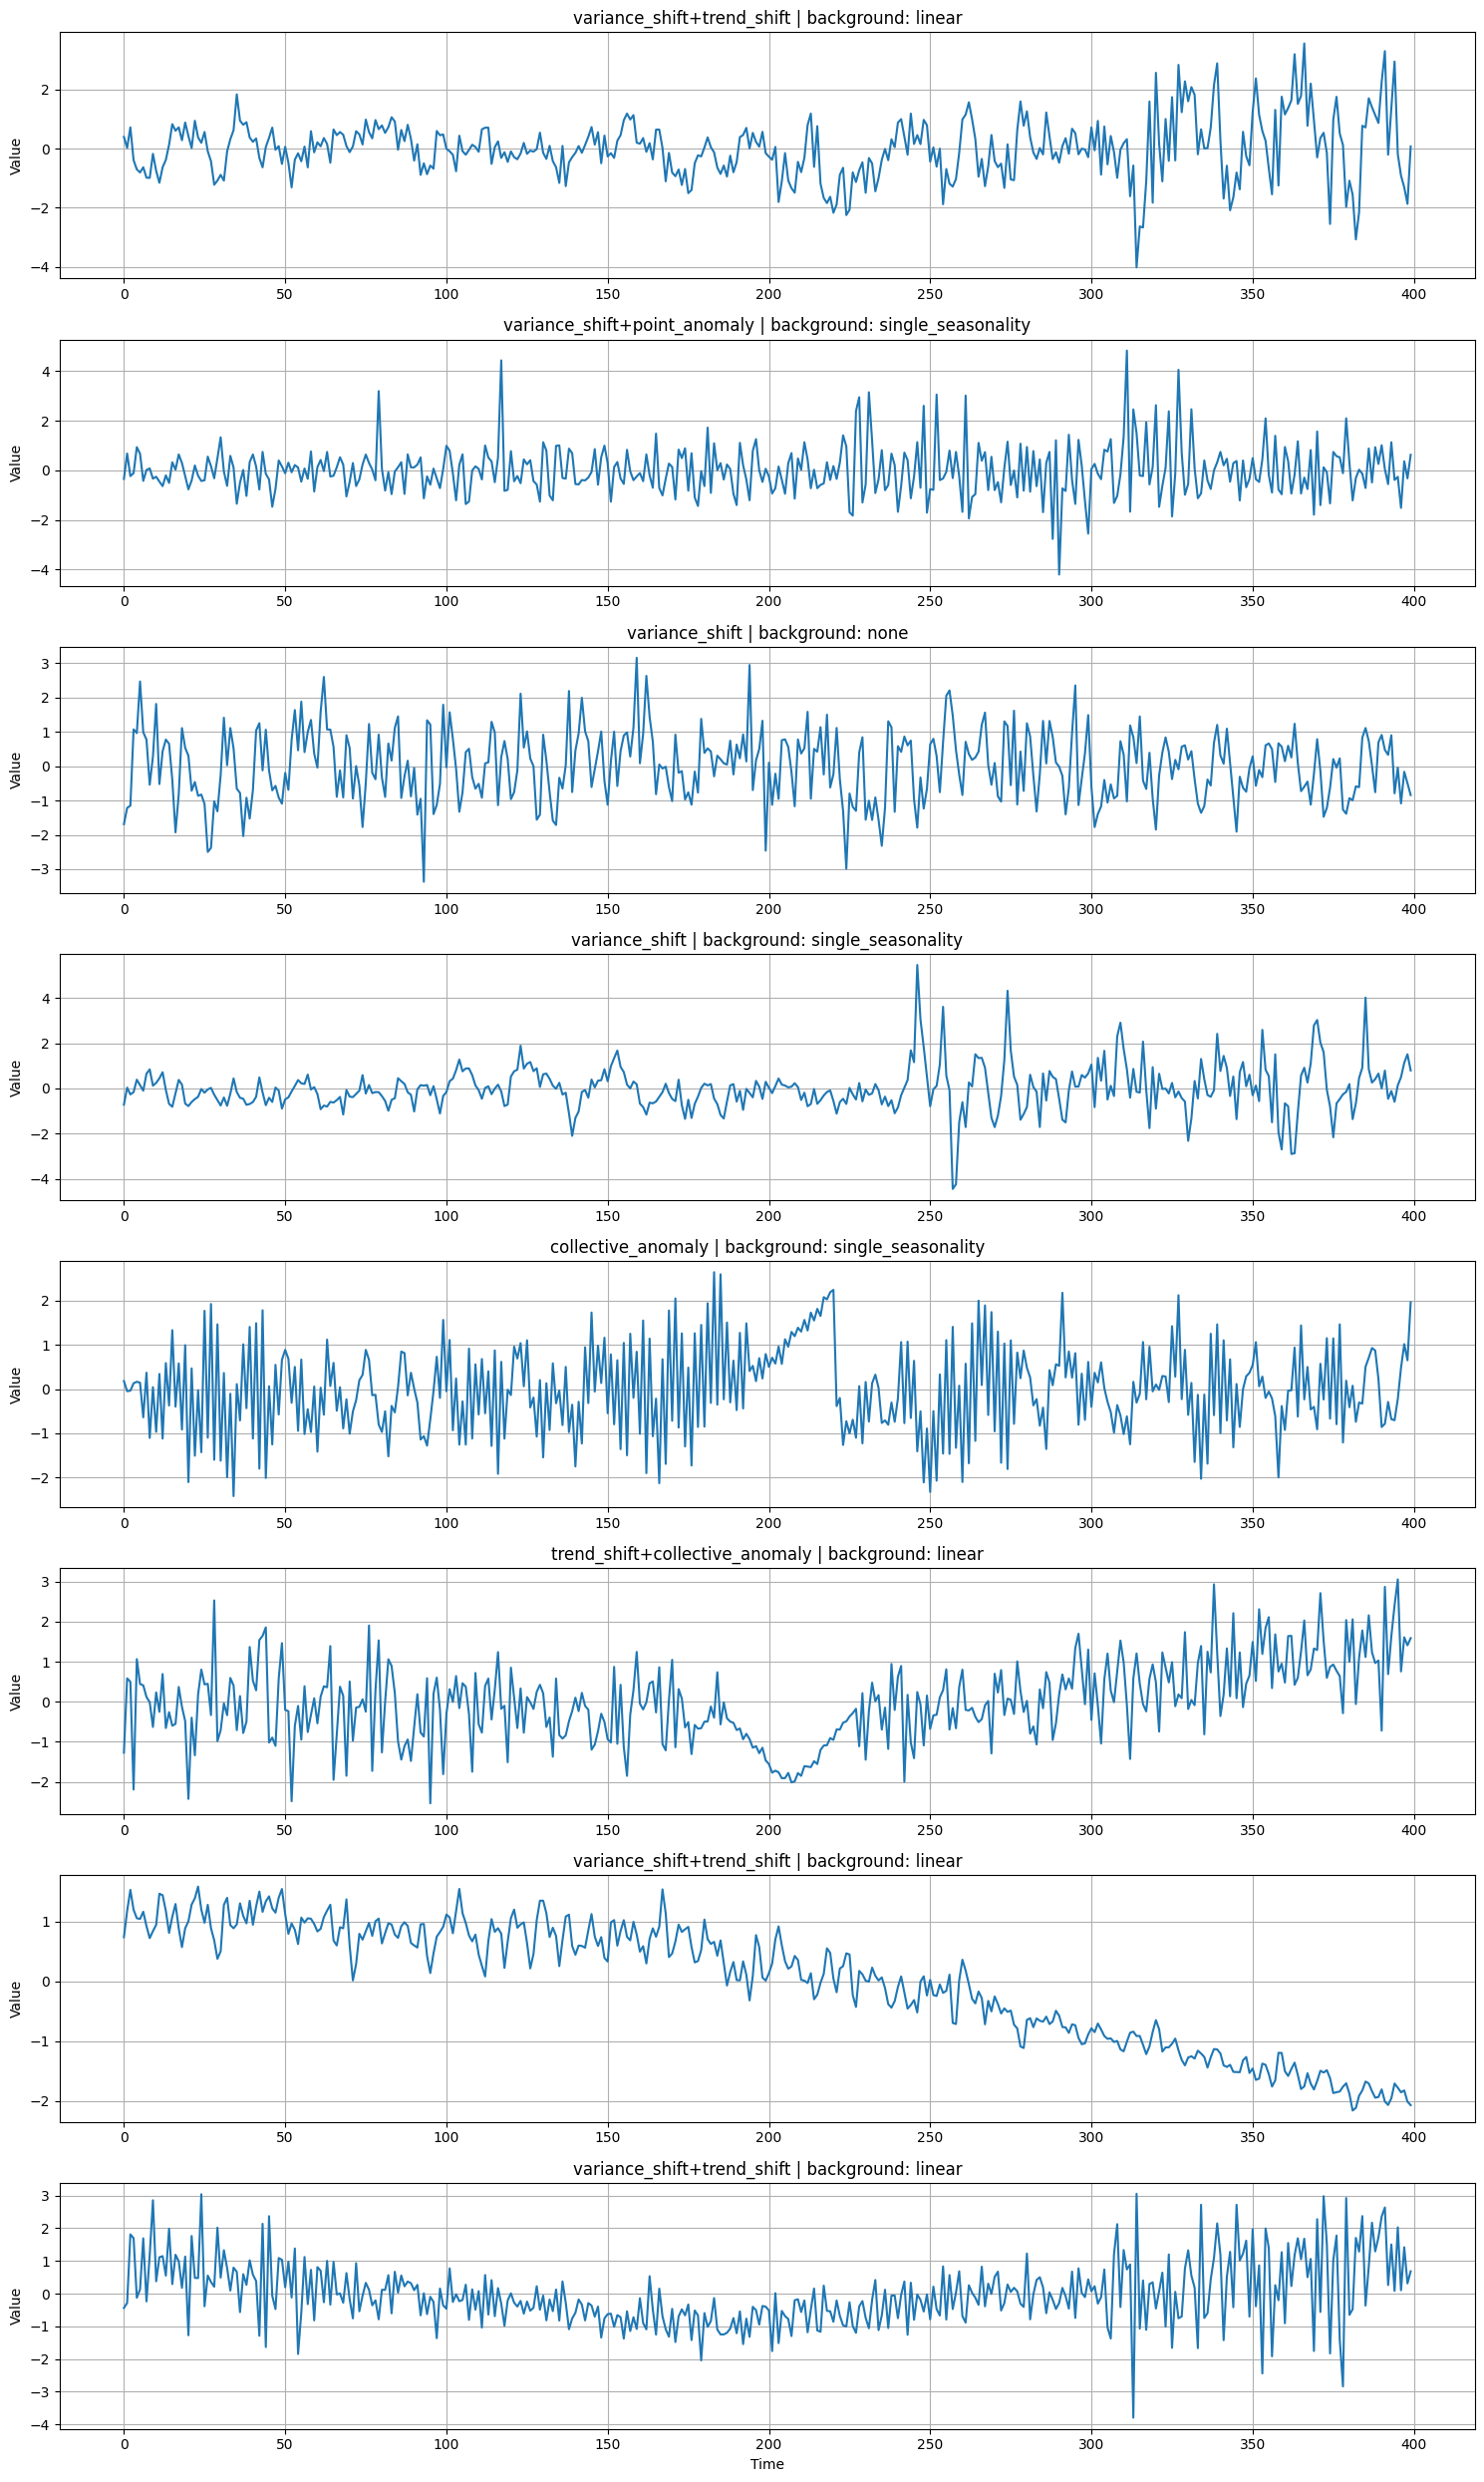

In [11]:
def plot_selected_examples_from_saved_arrays(arrays_to_save, all_metadata, split_name, length, n_examples=8):
    X = arrays_to_save[f"X_{split_name}_L{length}"]
    Y = arrays_to_save[f"Y_{split_name}_L{length}"]

    meta = all_metadata[
        (all_metadata["dataset"] == split_name) &
        (all_metadata["length"] == length)
    ].reset_index(drop=True)

    selected_indices = np.random.choice(len(meta), size=n_examples, replace=False)

    plt.figure(figsize=(15, 25))

    for plot_i, idx in enumerate(selected_indices, start=1):
        scenario = meta.loc[idx, "scenario"]
        background = meta.loc[idx, "background"]

        plt.subplot(n_examples, 1, plot_i)
        plt.plot(X[idx])
        plt.title(f"{scenario} | background: {background}")
        plt.ylabel("Value")
        plt.grid(True)

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


plot_selected_examples_from_saved_arrays(
    arrays_to_save=arrays_to_save,
    all_metadata=all_metadata,
    split_name="train",
    length=400,
    n_examples=8
)